In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph

In [3]:
class AgentState(TypedDict):
    name:str
    age:int
    skills:list[str]
    sentence:str

In [4]:
test1 = AgentState({'name':'ikrama','age':'21','skills':'python'})
test1.values()

dict_values(['ikrama', '21', 'python'])

In [64]:
def first_node(state:AgentState)->AgentState:
    state['sentence']= f"{state['name']} welcome to the system!"
    return state
def second_node(state:AgentState)->AgentState:
    state['sentence']= state['sentence'] + f" You are {state['age']} years old!"
    return state 

def third_node(state:AgentState)->AgentState:
    sentence = f"{', '.join(state['skills'][:-1])} & {state['skills'][-1]}"
    state['sentence'] = state['sentence'] + f" You have skills in {sentence}"
    return state

In [65]:
# test 
v1 = {'name':'ikku','age':21,'skills':['python','langchain','langgraph']}
first_node(v1)
second_node(v1)
third_node(v1)



{'name': 'ikku',
 'age': 21,
 'skills': ['python', 'langchain', 'langgraph'],
 'sentence': 'ikku welcome to the system! You are 21 years old! You have skills in python, langchain & langgraph'}

In [68]:

def frmt(stte:AgentState)->AgentState:
    result = ", ".join(stte["skills"][:-1]), "&",stte["skills"][-1]
    print(result)
    sentence = f"{', '.join(stte['skills'][:-1])} & {stte['skills'][-1]}"
    print(sentence)
frmt(v1)


('python, langchain', '&', 'langgraph')
python, langchain & langgraph


In [69]:
graph = StateGraph(AgentState)

graph.add_node('First_node',first_node)
graph.add_node('Second_node',second_node)
graph.add_node("Third_node",third_node)

graph.set_entry_point('First_node')
graph.add_edge("First_node","Second_node")
graph.add_edge("Second_node","Third_node")

graph.set_finish_point("Third_node")

app = graph.compile()

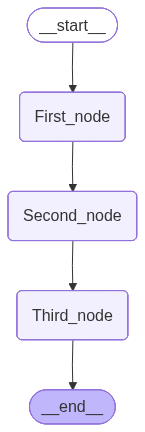

In [70]:
from IPython.display import display,Image
display(Image(app.get_graph().draw_mermaid_png()))

In [71]:
result = app.invoke({'name':'ikrama','age':21,'skills':['python','langchain' ,'langgraph']})
print(result['sentence'])

ikrama welcome to the system! You are 21 years old! You have skills in python, langchain & langgraph
